In [1]:
# Cel (22.08.2026): sugestia Homoli z komentarza 24.07 (przeczytana ponownie
# dzisiaj przez Maćka, patrz 20260822.txt): "porownanie optymalnych t0 dla
# roznych dekad i roznych stacji ... wybrac epoki wg cykli slonecznych,
# ekstremalne PPDF i odpowiadajace t0 per cykl, osobno dla d=1/d=5 ...
# globalne mapy efektu cykl do cyklu". Dotychczasowe skany (19-22.08) uzywaly
# TYLKO katalogu EQ 2005-2025 (~2 cykle) - za malo dla prawdziwej mapy
# cykl-do-cyklu. Dzisiaj rozszerzony katalog EQ do 1965-2025
# (download_usgs_extended_history.py) - to odblokowuje ten notebook.
#
# TEN notebook robi TYLKO wykrywanie cykli + budowe listy zadan + WLASCIWY,
# kosztowny skan (Maciek zaakceptowal 2h+ obliczen). Agregacja wynikow i
# mapy/wykresy sa CELOWO w OSOBNYM notebooku (20260822d.ipynb), ktory czyta
# TYLKO juz zapisane pliki z results/ - ta sama zasada bezpieczenstwa co przy
# rozdzieleniu 20260820a.ipynb (skan) / 20260820b.ipynb (wykresy) po
# incydencie z 20.08 (przypadkowe ponowne odpalenie "od gory" nie moze juz
# wywolac wielogodzinnego skanu).
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm
from scipy.signal import find_peaks
from statsmodels.nonparametric.smoothers_lowess import lowess

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

# Rozszerzony katalog EQ (1965-2025, pobrany dzisiaj) - NIE stary
# usgs_m4_2005_2025.csv, ktorego uzywaly wszystkie poprzednie notebooki.
USGS_EXTENDED_PATH = "../data/usgs_data/usgs_m4_1965_2025.csv"

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_EXTENDED_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


eq = load_earthquakes(min_mag=4.0)
print(f"EQ (M>=4.0, katalog rozszerzony): {len(eq)} zdarzen, {eq.index.min()} .. {eq.index.max()}")


EQ (M>=4.0, katalog rozszerzony): 507919 zdarzen, 1965-01-01 08:04:17.780000 .. 2025-01-31 23:57:39.481000


In [2]:
# Loadery CR - WSZYSTKIE 22 stacje. mosc/oulu jak zawsze (dedykowane pliki
# pelnej historii, 1960/1970-2025). Pozostale 20: preferuj NOWY katalog
# `data/csv_data_stations_extended/` (pelna historia per stacja, patrz
# download_stations_extended_history.py) - jesli jeszcze nie pobrany dla
# danej stacji, spadnij na `csv_data_stations_full6h/` (tylko 2005-2025,
# pobrane 20.08) - notebook dziala CZESCIOWO nawet przed ukonczeniem
# rozszerzonego pobrania, tylko z mniejsza liczba dostepnych cykli dla tych
# stacji (i automatycznie rozszerzy sie przy ponownym odpaleniu pozniej,
# dzieki wznawialnosci obu skryptow pobierajacych + pomijaniu istniejacych
# plikow wynikowych w komorce ze skanem nizej).
MOSC_PATH = "../data/mosc_data.csv"
OULU_PATH = "../data/oulu_5min_data.csv"
EXTENDED_DIR = "../data/csv_data_stations_extended"
FULL6H_DIR = "../data/csv_data_stations_full6h"

OTHER_STATIONS = [
    "THUL", "LMKS", "APTY", "SOPB", "JUNG1", "SOPO", "FSMT",
    "JUNG", "NEWK", "PWNK", "MXCO", "NAIN", "HRMS", "TERA", "INVK", "ATHN",
    "AATB", "PSNM", "NANM", "MCRL",
]


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu():
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    n_bad = df["datetime"].isna().sum()
    if n_bad:
        print(f"load_oulu: pominieto {n_bad} niesparsowalnych wierszy (uszkodzone dane)")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_station(station):
    ext_path = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full_path = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    if os.path.exists(ext_path):
        path, source = ext_path, "extended"
    elif os.path.exists(full_path):
        path, source = full_path, "full6h (TYLKO 2005-2025)"
    else:
        return None, None
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"], source


cr_series = {}
cr_series["mosc"] = load_mosc()
cr_series["oulu"] = load_oulu().resample("6h").mean()
print(f"mosc: {len(cr_series['mosc'])} pomiarow, {cr_series['mosc'].index.min()} .. {cr_series['mosc'].index.max()} (pelna historia)")
print(f"oulu: {len(cr_series['oulu'])} pomiarow, {cr_series['oulu'].index.min()} .. {cr_series['oulu'].index.max()} (pelna historia)")

limited_stations = []
for station in OTHER_STATIONS:
    s, source = load_station(station)
    if s is None:
        print(f"{station.lower()}: BRAK danych w ogole, pomijam")
        continue
    cr_series[station.lower()] = s
    print(f"{station.lower()}: {len(s)} pomiarow, {s.index.min()} .. {s.index.max()} (zrodlo: {source})")
    if source and "full6h" in source:
        limited_stations.append(station.lower())

if limited_stations:
    print(f"\nUWAGA: {len(limited_stations)} stacji ma na razie TYLKO dane 2005-2025 "
          f"(rozszerzone pobranie jeszcze niekompletne) - beda mialy zadania tylko dla "
          f"ostatnich 1-2 cykli: {limited_stations}")
    print("Uruchom skrypty_dl/wlasne/download_stations_extended_history.py i odpal ten "
          "notebook ponownie, zeby dostac wiecej cykli dla tych stacji (juz ukonczone "
          "zadania w results/ zostana pominiete, wiec nic nie liczy sie od nowa).")


load_oulu: pominieto 1 niesparsowalnych wierszy (uszkodzone dane)
mosc: 91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00 (pelna historia)
oulu: 81816 pomiarow, 1970-01-01 00:00:00 .. 2025-12-31 18:00:00 (pelna historia)
thul: 96178 pomiarow, 1957-08-13 12:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
lmks: 60784 pomiarow, 1981-12-01 00:00:00 .. 2023-07-10 18:00:00 (zrodlo: extended)
apty: 37234 pomiarow, 2000-07-01 00:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
sopb: 29044 pomiarow, 1997-12-31 00:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
jung1: 57538 pomiarow, 1986-01-01 00:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
sopo: 80347 pomiarow, 1964-03-01 00:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
fsmt: 36703 pomiarow, 2000-10-04 00:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
jung: 97003 pomiarow, 1958-10-01 06:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
newk: 89348 pomiarow, 1964-07-01 00:00:00 .. 2025-12-31 18:00:00 (zrodlo: extended)
pwnk: 34251 p

Wykryte minima cykli slonecznych (25):
  1755-10-01
  1766-03-01
  1775-07-01
  1784-06-01
  1798-02-01
  1810-07-01
  1823-01-01
  1833-10-01
  1843-10-01
  1856-02-01
  1867-03-01
  1878-10-01
  1889-07-01
  1901-09-01
  1913-03-01
  1923-04-01
  1933-11-01
  1944-02-01
  1954-04-01
  1964-11-01
  1976-02-01
  1986-05-01
  1996-06-01
  2008-11-01
  2019-09-01


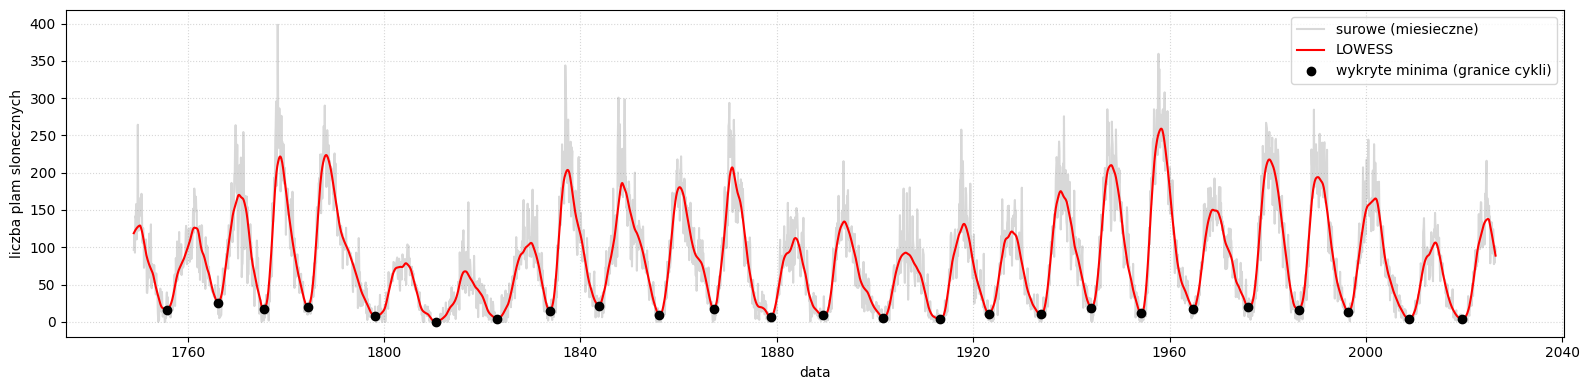


6 segmentow cykli w zakresie katalogu EQ:
  cycle_1964: 1965-01-01 .. 1976-02-01 (11.1 lat)
  cycle_1976: 1976-02-01 .. 1986-05-01 (10.2 lat)
  cycle_1986: 1986-05-01 .. 1996-06-01 (10.1 lat)
  cycle_1996: 1996-06-01 .. 2008-11-01 (12.4 lat)
  cycle_2008: 2008-11-01 .. 2019-09-01 (10.8 lat)
  cycle_2019_incomplete: 2019-09-01 .. 2025-01-31 (5.4 lat)


In [3]:
# Wykrywanie granic cykli slonecznych: LOWESS + find_peaks NA ODWROCONYM
# sygnale (szukamy MINIMOW, nie maksimow jak w 20260703-20260708.ipynb -
# minima sa naturalnymi granicami miedzy cyklami). Ten sam LOWESS frac=0.01
# co w 20260708.ipynb (juz sprawdzone, stabilne). distance=100 (probek =
# miesiecy, ~8.3 roku) < najkrotszy znany cykl sloneczny (~9 lat), zeby nie
# zgubic zadnego prawdziwego minimum, a odfiltrowac drobne falowania.
sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))

x = sn["rok_norm"].values
y = sn["sunspot"].values
smoothed = lowess(y, x, frac=0.01)[:, 1]

min_idx, _ = find_peaks(-smoothed, distance=100, prominence=5)
cycle_min_dates = pd.to_datetime(sn["date"].values[min_idx])

print(f"Wykryte minima cykli slonecznych ({len(cycle_min_dates)}):")
for d in cycle_min_dates:
    print(f"  {d.date()}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(sn["date"], sn["sunspot"], color="gray", alpha=0.3, label="surowe (miesieczne)")
ax.plot(sn["date"], smoothed, color="red", label="LOWESS")
ax.plot(cycle_min_dates, smoothed[min_idx], "o", color="black", label="wykryte minima (granice cykli)")
ax.set_xlabel("data")
ax.set_ylabel("liczba plam slonecznych")
ax.legend()
ax.grid(ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

# Segmenty cykli [min_i, min_{i+1}) - tylko te pokrywajace sie z zakresem
# katalogu EQ (1965-2025). Ostatni, NIEDOKONCZONY cykl (od ostatniego
# minimum do konca danych) tez dodany - bedzie mial malo/krotki zakres
# kandydatow t0, ale run_t0_scan_parallel/cosmoseismic_stat i tak odrzuca
# kandydatow bez pelnego pokrycia (patrz komorka z lista zadan nizej).
cycles = []
for i in range(len(cycle_min_dates) - 1):
    start, end = cycle_min_dates[i], cycle_min_dates[i + 1]
    if end < eq.index.min() or start > eq.index.max():
        continue
    cycles.append(dict(
        label=f"cycle_{start.year}",
        start=max(start, eq.index.min()),
        end=min(end, eq.index.max()),
    ))

if len(cycle_min_dates) and cycle_min_dates[-1] <= eq.index.max():
    last_start = cycle_min_dates[-1]
    cycles.append(dict(
        label=f"cycle_{last_start.year}_incomplete",
        start=last_start, end=eq.index.max(),
    ))

print(f"\n{len(cycles)} segmentow cykli w zakresie katalogu EQ:")
for c in cycles:
    print(f"  {c['label']}: {c['start'].date()} .. {c['end'].date()} ({(c['end']-c['start']).days/365.25:.1f} lat)")


In [4]:
# Parametry skanu. d i m jak zawsze. P_DAYS_VALUES = OBA okna z sekcji 4
# artykulu (Fig. 4 - analiza cykli slonecznych 1965-2015 uzywa DOKLADNIE
# 1675d I 3350d, patrz 20260819.txt pkt 7), nie tylko 3350d jak w
# dotychczasowych skanach "replikacyjnych" (19-22.08) - to jest teraz
# WLASCIWY kontekst na uzycie obu.
#
# T0_STEP = 24h, CELOWO grubszy niz 6h uzywane dotychczas. Powod: (1) koszt
# - przy 6h kazdy z ~10-20 kombinacji stacja x cykl x P_days x d kosztowalby
# tyle co caly wczorajszy skan 22-stacyjny (~309s/68s na kombinacje), co przy
# 5-6 cyklach x 22 stacjach dawaloby rzedu dziesiatek godzin; przy 24h (4x
# mniej kandydatow) to spada do rzedu 1-2 godzin (patrz szacunek w komorce
# zadan nizej); (2) do celu "ekstremalne PPDF per cykl" (nie precyzyjne
# wyznaczenie dnia t0) taka gestosc probkowania jest wystarczajaca, a jako
# dodatkowy plus lekko zmniejsza liczbe silnie skorelowanych kandydatow
# (mniejszy efekt look-elsewhere niz przy 6h) - patrz zastrzezenia o tym
# problemie w 20260819.txt/20260820.txt.
D_VALUES = [1, 5]
P_DAYS_VALUES = [1675, 3350]
DT_DAYS = 0
M_THRESHOLD = 4.0
T0_STEP = "24h"

print(f"D_VALUES={D_VALUES}, P_DAYS_VALUES={P_DAYS_VALUES}, T0_STEP={T0_STEP}")


D_VALUES=[1, 5], P_DAYS_VALUES=[1675, 3350], T0_STEP=24h


In [5]:
# Budowa listy zadan (stacja x cykl x P_days x d) + PODGLAD KOSZTU przed
# odpaleniem wlasciwego skanu w nastepnej komorce. Zadanie pomijane, jesli
# w danym cyklu/P_days nie ma ani jednego poprawnego kandydata t0 (np.
# stacja za mloda dla tego cyklu, albo okno P_days nie miesci sie w
# dostepnym katalogu EQ dla tego cyklu - dotyczy m.in. ostatniego,
# niedokonczonego cyklu przy P_days=3350).
tasks = []
for cyc in cycles:
    for P_days in P_DAYS_VALUES:
        t0_first = cyc["start"].ceil(T0_STEP)
        t0_last = min(cyc["end"], eq.index.max() - pd.Timedelta(days=P_days)).floor(T0_STEP)
        if t0_last <= t0_first:
            continue
        t0_candidates = pd.date_range(t0_first, t0_last, freq=T0_STEP)

        cr_lo, cr_hi = t0_first, t0_last + pd.Timedelta(days=P_days)
        for name, cr in cr_series.items():
            cr_cyc = cr[(cr.index >= cr_lo) & (cr.index <= cr_hi)]
            if len(cr_cyc) == 0:
                continue
            for d in D_VALUES:
                tasks.append(dict(
                    cycle=cyc["label"], station=name, P_days=P_days, d=d,
                    t0_candidates=t0_candidates, cr=cr_cyc,
                    n_candidates=len(t0_candidates),
                ))

print(f"Liczba zadan (stacja x cykl x P_days x d): {len(tasks)}")

preview = pd.DataFrame([{k: v for k, v in t.items() if k not in ("t0_candidates", "cr")} for t in tasks])
if len(preview):
    print("\nZadania per P_days/d:")
    print(preview.groupby(["P_days", "d"])["n_candidates"].agg(["count", "sum"]))
    print("\nZadania per cykl:")
    print(preview.groupby("cycle")["station"].apply(lambda s: sorted(s.tolist())))

    # Zgrubny szacunek czasu na podstawie benchmarku z 19-20.08 (6h, P=3350,
    # d=1: ~309s/11-letni zakres [~16000 kand.], d=5: ~68s) - przeskalowany
    # liniowo po liczbie kandydatow (24h step = ~4x mniej kandydatow niz 6h
    # dla tego samego zakresu, P=1675 ma o polowe mniej binow niz P=3350).
    BENCH_SEC_PER_CANDIDATE = {1: 309 / 15943, 5: 68 / 15943}
    preview["est_sec"] = preview.apply(
        lambda r: r["n_candidates"] * BENCH_SEC_PER_CANDIDATE[r["d"]] * (r["P_days"] / 3350), axis=1
    )
    total_min = preview["est_sec"].sum() / 60
    print(f"\nZGRUBNY szacunek calkowitego czasu: {total_min:.0f} minut (~{total_min/60:.1f}h)")


Liczba zadan (stacja x cykl x P_days x d): 386

Zadania per P_days/d:
          count     sum
P_days d               
1675   1    107  348626
       5    107  348626
3350   1     86  315802
       5     86  315802

Zadania per cykl:
cycle
cycle_1964               [aatb, aatb, aatb, aatb, hrms, hrms, hrms, hrm...
cycle_1976               [aatb, aatb, aatb, aatb, hrms, hrms, hrms, hrm...
cycle_1986               [aatb, aatb, aatb, aatb, apty, apty, apty, apt...
cycle_1996               [aatb, aatb, aatb, aatb, apty, apty, apty, apt...
cycle_2008               [aatb, aatb, aatb, aatb, apty, apty, apty, apt...
cycle_2019_incomplete    [aatb, aatb, apty, apty, athn, athn, fsmt, fsm...
Name: station, dtype: object

ZGRUBNY szacunek calkowitego czasu: 193 minut (~3.2h)


In [6]:
# WLASCIWY SKAN - kosztowna komorka, potencjalnie GODZINY obliczen (patrz
# szacunek w komorce wyzej; Maciek zaakceptowal 2h+, 20260822.txt).
#
# Zapis do results/cycle_scan_{stacja}_{cykl}_P{Pdays}_d{d}.csv, ATOMOWY per
# zadanie (run_t0_scan_parallel zapisuje dopiero po ukonczeniu calego skanu
# danego zadania - jak dotychczas, patrz 20260820.txt pkt 11) - przerwanie w
# trakcie NIE psuje juz zapisanych wynikow. WZNAWIALNE: zadania z juz
# istniejacym plikiem wyjsciowym sa pomijane - bezpiecznie przerwac
# (Ctrl+C / restart kernela) i odpalic ponownie, tez PO uzupelnieniu danych
# przez download_stations_extended_history.py (wtedy pojawia sie WIECEJ
# zadan dla stacji, ktore dzis mialy tylko czesciowa historie).
#
# ZALECENIE: uruchamiac w tle (nie interaktywnie) - np. `jupyter nbconvert
# --to notebook --execute` w screen/nohup, albo zostawic to okno Jupytera
# odpalone i nie czekac przy komputerze.
RESULTS_DIR = "../results"
t_session_start = time.time()

for i, task in enumerate(tasks):
    out_path = f"{RESULTS_DIR}/cycle_scan_{task['station']}_{task['cycle']}_P{task['P_days']}_d{task['d']}.csv"
    if os.path.exists(out_path):
        continue
    print(f"[{i+1}/{len(tasks)}] {task['station']} {task['cycle']} P={task['P_days']} d={task['d']} "
          f"({task['n_candidates']} kandydatow)...")
    t_task_start = time.time()
    run_t0_scan_parallel(
        task["cr"], eq, task["t0_candidates"],
        P_days=task["P_days"], d_days=task["d"], m=M_THRESHOLD, dt_days=DT_DAYS,
        stat_fn=cosmoseismic_stat,
        save_path=out_path,
    )
    elapsed_task = time.time() - t_task_start
    elapsed_total = (time.time() - t_session_start) / 60
    print(f"  gotowe w {elapsed_task:.1f}s (laczny czas tej sesji: {elapsed_total:.1f} min)")

print("\nWszystkie zadania ukonczone (albo juz wczesniej istnialy na dysku).")


[239/386] hrms cycle_1996 P=3350 d=1 (4537 kandydatow)...
  gotowe w 89.0s (laczny czas tej sesji: 1.5 min)
[240/386] hrms cycle_1996 P=3350 d=5 (4537 kandydatow)...
  gotowe w 19.7s (laczny czas tej sesji: 1.8 min)
[241/386] tera cycle_1996 P=3350 d=1 (4537 kandydatow)...
  gotowe w 88.7s (laczny czas tej sesji: 3.3 min)
[242/386] tera cycle_1996 P=3350 d=5 (4537 kandydatow)...
  gotowe w 20.2s (laczny czas tej sesji: 3.6 min)
[243/386] invk cycle_1996 P=3350 d=1 (4537 kandydatow)...
  gotowe w 90.2s (laczny czas tej sesji: 5.1 min)
[244/386] invk cycle_1996 P=3350 d=5 (4537 kandydatow)...
  gotowe w 19.9s (laczny czas tej sesji: 5.5 min)
[245/386] athn cycle_1996 P=3350 d=1 (4537 kandydatow)...
  gotowe w 89.1s (laczny czas tej sesji: 6.9 min)
[246/386] athn cycle_1996 P=3350 d=5 (4537 kandydatow)...
  gotowe w 19.7s (laczny czas tej sesji: 7.3 min)
[247/386] aatb cycle_1996 P=3350 d=1 (4537 kandydatow)...
  gotowe w 88.5s (laczny czas tej sesji: 8.8 min)
[248/386] aatb cycle_1996 P=

/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN sli

  gotowe w 88.3s (laczny czas tej sesji: 10.6 min)
[250/386] psnm cycle_1996 P=3350 d=5 (4537 kandydatow)...


/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN sli

  gotowe w 19.4s (laczny czas tej sesji: 10.9 min)
[251/386] nanm cycle_1996 P=3350 d=1 (4537 kandydatow)...
  gotowe w 89.8s (laczny czas tej sesji: 12.4 min)
[252/386] nanm cycle_1996 P=3350 d=5 (4537 kandydatow)...
  gotowe w 19.9s (laczny czas tej sesji: 12.7 min)
[253/386] mcrl cycle_1996 P=3350 d=1 (4537 kandydatow)...


...

  gotowe w 0.8s (laczny czas tej sesji: 56.5 min)
[373/386] tera cycle_2019_incomplete P=1675 d=1 (305 kandydatow)...
  gotowe w 3.2s (laczny czas tej sesji: 56.6 min)
[374/386] tera cycle_2019_incomplete P=1675 d=5 (305 kandydatow)...
  gotowe w 0.8s (laczny czas tej sesji: 56.6 min)
[375/386] invk cycle_2019_incomplete P=1675 d=1 (305 kandydatow)...
  gotowe w 3.2s (laczny czas tej sesji: 56.6 min)
[376/386] invk cycle_2019_incomplete P=1675 d=5 (305 kandydatow)...
  gotowe w 0.8s (laczny czas tej sesji: 56.6 min)
[377/386] athn cycle_2019_incomplete P=1675 d=1 (305 kandydatow)...
  gotowe w 3.2s (laczny czas tej sesji: 56.7 min)
[378/386] athn cycle_2019_incomplete P=1675 d=5 (305 kandydatow)...
  gotowe w 0.8s (laczny czas tej sesji: 56.7 min)
[379/386] aatb cycle_2019_incomplete P=1675 d=1 (305 kandydatow)...
  gotowe w 3.2s (laczny czas tej sesji: 56.8 min)
[380/386] aatb cycle_2019_incomplete P=1675 d=5 (305 kandydatow)...
  gotowe w 0.8s (laczny czas tej sesji: 56.8 min)
[381/3

/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN sli

  gotowe w 3.2s (laczny czas tej sesji: 57.0 min)
[386/386] mcrl cycle_2019_incomplete P=1675 d=5 (305 kandydatow)...


/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN slice encountered
  med_dCR = np.nanmedian(np.abs(dCR))
/tmp/ipykernel_5386/752583260.py:61: RuntimeWarning: All-NaN sli

  gotowe w 0.8s (laczny czas tej sesji: 57.0 min)

Wszystkie zadania ukonczone (albo juz wczesniej istnialy na dysku).
